### INTRODUCTION

### Traffic Data Exploration

This notebook focuses on exploring the traffic dataset to understand patterns, relationships, and key factors affecting traffic volume. Visualizations and summary statistics are used to gain insights that will guide model building.

### Import Libraries and Load Dataset

This section imports the required libraries and loads the dataset for exploration.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/traffic_data.csv")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


### Check Missing Values

This checks for missing values in the dataset to understand data quality and identify if cleaning is required.

In [2]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

### Explore Weather Categories

This shows the distribution of different weather conditions in the dataset.

In [3]:
df['weather_main'].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

### Traffic Volume Distribution

This visualizes how traffic volume is distributed across the dataset.

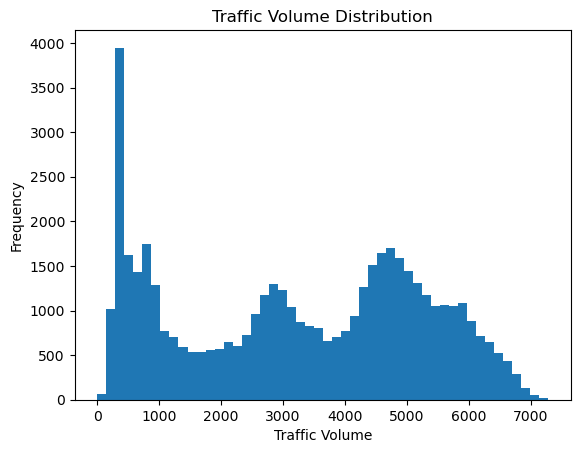

In [4]:
import matplotlib.pyplot as plt

plt.hist(df['traffic_volume'], bins=50)
plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

### Median Traffic Volume

This calculates the median traffic volume, which will later be used as a threshold for classification.

In [5]:
df['traffic_volume'].median()

3380.0

### Traffic Distribution with Median

This visualization shows the traffic distribution along with the median value for better understanding of the threshold.

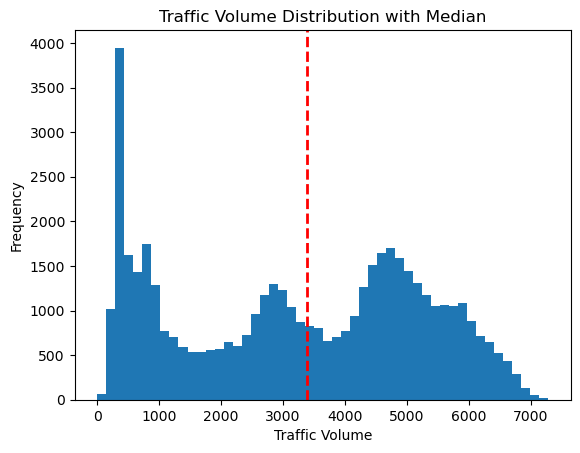

In [6]:
import matplotlib.pyplot as plt

plt.hist(df['traffic_volume'], bins=50)
plt.axvline(df['traffic_volume'].median(), color='red', linestyle='dashed', linewidth=2)

plt.title("Traffic Volume Distribution with Median")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

### Extract Time Features

This converts the date column and extracts useful time-based features such as hour and day of the week for analysis.

In [7]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1


### Traffic Pattern by Hour

This shows how traffic volume changes throughout the day.

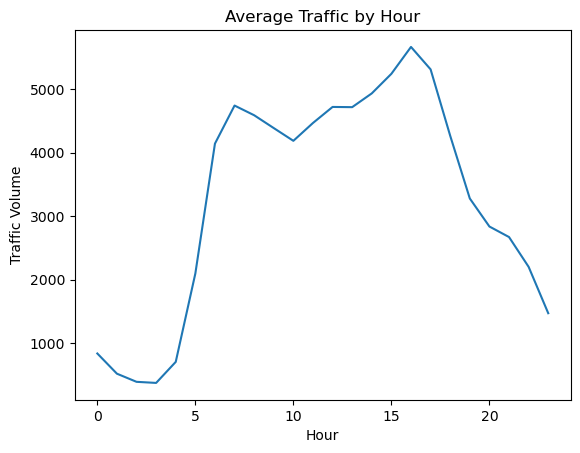

In [8]:
df.groupby('hour')['traffic_volume'].mean().plot()
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.show()

### Traffic vs Weather

This explores how different weather conditions affect traffic volume.

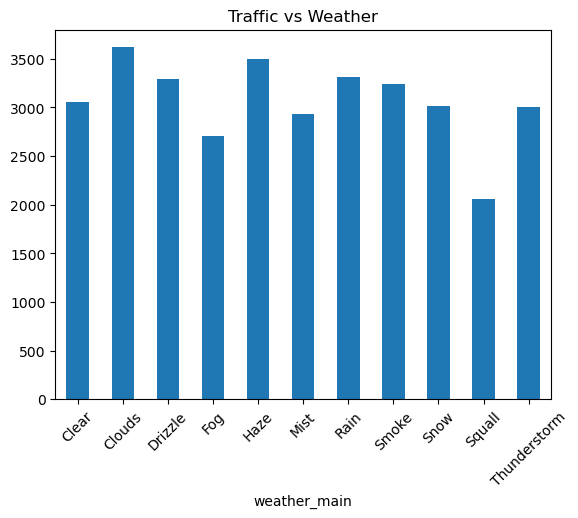

In [9]:
df.groupby('weather_main')['traffic_volume'].mean().plot(kind='bar')
plt.title("Traffic vs Weather")
plt.xticks(rotation=45)
plt.show()

### Select Numeric Features

This selects only numerical columns for correlation analysis.

In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

### Correlation Heatmap

This visualizes relationships between numerical features to identify patterns and dependencies.

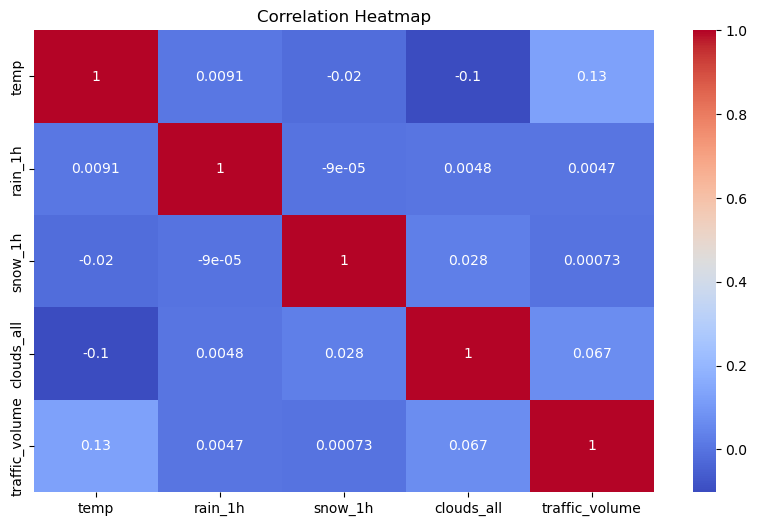

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Summary of Data Exploration

This notebook explored the traffic dataset to understand key patterns and relationships. The analysis showed that traffic volume varies significantly based on time, particularly by hour and day of the week, confirming the importance of temporal features.

The distribution of traffic volume revealed a natural midpoint (median), which supports its use in defining traffic levels (High vs Low). Weather conditions also showed some influence on traffic patterns, though their impact appears less significant compared to time-based features.

Correlation analysis helped identify relationships between numerical variables, guiding feature selection for the model.

Overall, the insights gained from this exploration informed the feature engineering and modeling approach used in the project.